### 목표 설정
- 손 글씨 숫자(0~9)를 분류하는 모델을 만들어보자.
- 선형 분류 모델의 불확실성에 대해 알아보자(다른 분류도 살펴보자.)
- 이미지 데이터에 대한 형태를 이해해보자.

In [1]:
# 필요한 라이브러리 import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

### 데이터 확보
- digit_train 데이터 불러오기

In [2]:
digit = pd.read_csv('./data/digit_train.csv')

In [3]:
# 데이터 확인
# 주의점 : 데이터가 너무 크다. 그대로 불러오면 메모리가 버티지 못한다.
# head() 함수를 이용해서 데이터의 형태를 알아보자
digit.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
digit.shape

(42000, 785)

### EDA

In [5]:
# 하나의 데이터를 뽑아와서 데이터의 구조를 살펴보자.
img0 = digit.iloc[0, 1:]

In [6]:
# 뽑아온 데이터의 최댓값과 최소값을 알아보자
print(max(img0))
print(min(img0))

255
0


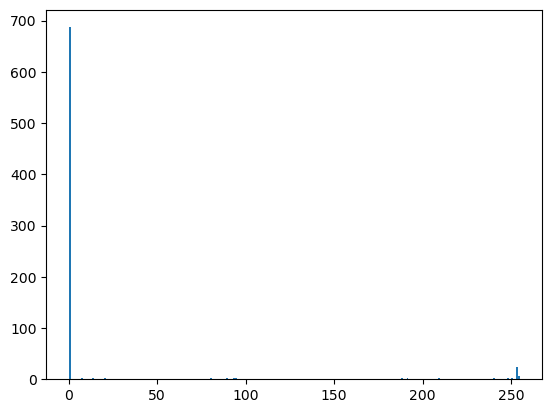

In [7]:
# 데이터의 분포를 알아보기 위해 히스토그램을 그려보자
plt.hist(img0, bins = 255)
plt.show()

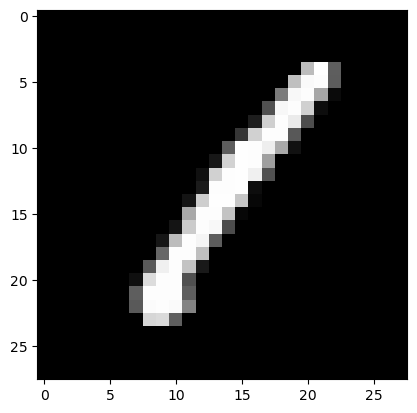

In [8]:
# 실제 데이터 출력해보기
plt.imshow(img0.values.reshape(28, 28), cmap = 'gray')
plt.show()
# 검정색은 0이였다. 흰색은 255였다.
# 히스토그램에서 중간 부분의 작은 데이터들은 숫자의 경계선을 표시하는것 같다.

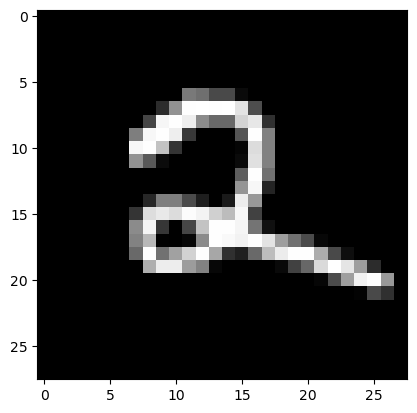

In [9]:
# 하나의 데이터를 뽑아와서 데이터의 구조를 살펴보자.
img0 = digit.iloc[41000, 1:]
# 실제 데이터 출력해보기
plt.imshow(img0.values.reshape(28, 28), cmap = 'gray')
plt.show()

### 데이터 추출
- 현재 데이터는 양이 너무 많다.
- 실습의 편의성을 위해서 우리가 5000개의 데이터를 뽑아오자.

In [10]:
X = digit.iloc[0 : 5000, 1 : ]
y = digit.iloc[0 : 5000, 0]
print(X.shape)
print(y.shape)

(5000, 784)
(5000,)


In [11]:
# 데이터 분할 작업 필요
# train_test_split을 이용해서 데이터를 분할 해주자
# 1. 모듈 불러오기
from sklearn.model_selection import train_test_split

In [12]:
# 2. 모듈 사용해서 4등분 해주기
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                   random_state=4)

In [13]:
# 3. 데이터 분할 확인하기
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3500, 784), (1500, 784), (3500,), (1500,))

### 모델링
- 로지스틱 회귀 모델을 사용해서 손글씨를 분류 해보자.

In [14]:
# 모델 import
from sklearn.linear_model import LogisticRegression

In [15]:
# 모델 객체 생성
logi = LogisticRegression() # 기본 모델 이용

In [16]:
import warnings
warnings.filterwarnings('ignore')
# 모델 학습
logi.fit(X_train, y_train)

LogisticRegression()

In [17]:
# 모델 예측
pre = logi.predict(X_test)
pre

array([3, 8, 8, ..., 9, 6, 9], dtype=int64)

In [18]:
# 교차 검증 - cross_val_score -> model_selection에 위치


In [38]:
# 교차검증 모듈 불러오기
from sklearn.model_selection import cross_val_score

In [20]:
# 교차검증 모듈 확인하기
result = cross_val_score(logi, X_train, y_train, cv = 5)
print(result)
print(result.mean())

[0.84142857 0.86       0.86142857 0.86142857 0.85857143]
0.8565714285714285


In [21]:
# 모델 평가
logi.score(X_test, y_test)

0.878

### 데이터 스케일링
- 모델의 안정성과 성능을 끌어올리기 위해서 데이터 스케일링 진행!
- 분류모델이기 때문에 상대적으로 더 어울리는 스탠다드 스케일링 작업을 진행

In [22]:
# 스케일링 모듈 불러오기
# 1. standard scaler
from sklearn.preprocessing import StandardScaler
# 2. MinMax Scaler
from sklearn.preprocessing import MinMaxScaler

In [23]:
# 모듈이 같은 위치에 존재할때는 콤마를 통해 여러 모듈을 불러올 수 있다.
# from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [24]:
# 스케일러 객체 생성
ss_scale = StandardScaler()
mm_scale = MinMaxScaler()

In [25]:
# 스케일러 학습
# 1. 스탠다드 스케일러 학습
ss_scale.fit(X_train)
# 2. MinMax 스케일러 학습
mm_scale.fit(X_train)

MinMaxScaler()

In [28]:
# 1. 스탠다드 스케일러를 통한 변환 진행하기
X_train_ss = ss_scale.transform(X_train)
X_test_ss = ss_scale.transform(X_test)

(array([ 54., 103., 114., 334., 137.,   2.,   5.,  18.,  12.,   5.]),
 array([-1.19061878, -0.89687553, -0.60313229, -0.30938905, -0.01564581,
         0.27809743,  0.57184067,  0.86558392,  1.15932716,  1.4530704 ,
         1.74681364]),
 <BarContainer object of 10 artists>)

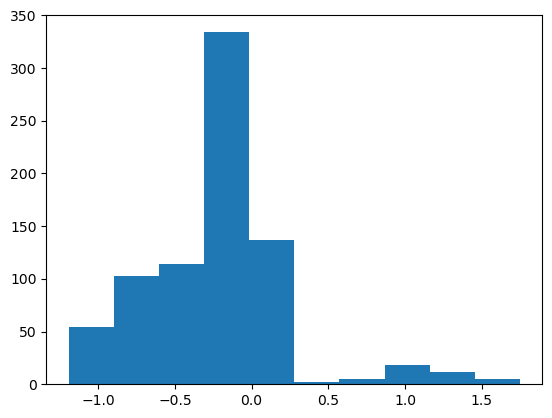

In [29]:
# 히스토그램 확인해보기
plt.hist(X_train_ss[0])

In [30]:
# 1. MinMax Scaler를 통한 데이터 스케일링 변환
X_train_mm = mm_scale.transform(X_train)
X_test_mm = mm_scale.transform(X_test)

(array([718.,   4.,   7.,  10.,   3.,   2.,   3.,   0.,   7.,  30.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

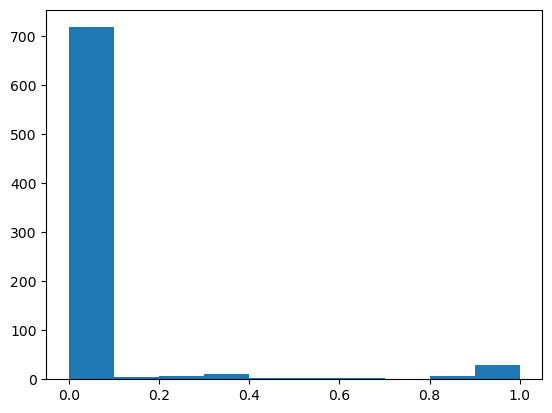

In [31]:
# 히스토그램 확인해보기
plt.hist(X_train_mm[0])

In [41]:
# 스케일링이 진행된 데이터를 가지고 모델을 학습
# 모델 객체 생성 - 변수명 : logi_ss
logi_ss = LogisticRegression()

In [42]:
# 스탠다드 스케일링된 데이터 학습
logi_ss.fit(X_train, y_train)

LogisticRegression()

In [43]:
# 스탠다드 스케일링된 데이터 교차검증
result = cross_val_score(logi_ss, X_train_ss, y_train, cv = 5)
print(result)
print(result.mean())

[0.87       0.89142857 0.88714286 0.87285714 0.88285714]
0.8808571428571428


In [45]:
# 스탠다드 스케일링된 데이터 모델 평가
logi_ss.score(X_test_ss, y_test)

0.7906666666666666

In [46]:
# 모델 객체 생성 - 변수명 : logi_mm
logi_mm = LogisticRegression()

In [50]:
# MinMax 스케일링된 데이터 학습
logi_mm.fit(X_train_mm, y_train)

LogisticRegression()

In [51]:
# MinMax 스케일링된 데이터 교차검증
result = cross_val_score(logi_mm, X_train_mm, y_train, cv = 5)
print(result)
print(result.mean())

[0.86285714 0.88857143 0.89285714 0.87285714 0.89      ]
0.8814285714285713


In [52]:
# MinMax 스케일링된 데이터 모델 평가
logi_mm.score(X_test_mm, y_test)

0.9073333333333333

### knn, tree 모델 사용해보기

In [53]:
# 모델 import
from sklearn.neighbors import KNeighborsClassifier # knn 모델
from sklearn.tree import DecisionTreeClassifier # 결정트리 모델

In [54]:
# 모델 객체 생성
knn_model = KNeighborsClassifier()
tree_model = DecisionTreeClassifier()

In [55]:
# 모델 학습
knn_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [56]:
# 모델평가
knn_model.score(X_test, y_test)

0.9273333333333333

### 분류의 불확실성
- 분류가 진행이 되고있다. 어떤 방법으로 분류를 해내는 걸까?

In [57]:
# predict_proba() : 분류를 진행할때 각 정답별 확률정보를 표시해주는 함수
# 각각의 값은 0~1 사이의 실수값으로 표시, 전체 합은 1을 넘지 않음 -> 1
knn_model.predict_proba(X_test[100 : 200])

array([[0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.2, 0. , 0. , 0. , 0. , 0.2, 0. , 0.6],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0.4, 0.6, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.4, 0.4, 0. , 0. , 0. , 0.2, 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.8, 0. , 0.2, 0. , 0. , 0. , 0. 

In [58]:
tree_model.predict_proba(X_test[100 : 200])

array([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 

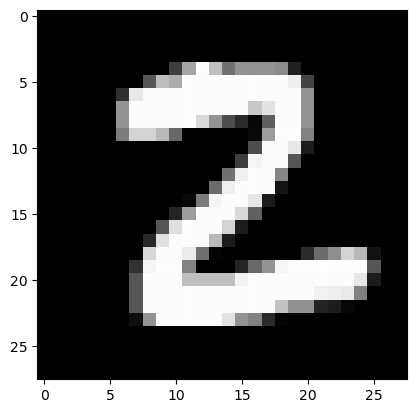

In [59]:
img0 = X_test.iloc[100]
plt.imshow(img0.values.reshape(28, 28), cmap='gray')